# Load libraries

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as skl
import anndata as ann
import random, os
from scipy.stats import pearsonr as pr
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score as f1
from sklearn.metrics import precision_recall_curve as prc
from sklearn.metrics import silhouette_score as sil
from sklearn.metrics import auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, average_precision_score
from sklearn.metrics import silhouette_score
from torch_geometric.nn import TransformerConv
from torch_geometric.data import Data
import gc, psutil

In [ ]:
import torch
import torch_geometric
from torch_geometric.nn import GraphConv, GCNConv
from sklearn.model_selection import StratifiedKFold
import scanpy as sc
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import torch_geometric.nn as pyg_nn
from torch_geometric.data import Data
from torch_geometric.utils import from_scipy_sparse_matrix
from sklearn.preprocessing import LabelEncoder
from torch_geometric.loader import NeighborLoader


In [ ]:
sc.set_figure_params(dpi=200)

In [ ]:
import torch
from torch_geometric.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader
from tqdm import tqdm  # For progress bar
from sklearn.model_selection import KFold

# Set random seeds for reproducibility
import random
import numpy as np
import torch

def set_random_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)  # if using CUDA
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_random_seeds(42)
# Check if GPU is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from tqdm import tqdm
from torch.nn import Linear, Dropout
from torch_geometric.nn import TransformerConv
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, accuracy_score


In [ ]:
from torch_geometric.data import Data
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder

In [ ]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from torch_geometric.loader import RandomNodeLoader
from torch_geometric.utils import subgraph

In [ ]:
def memory_usgae():
    gc.collect()
    process = psutil.Process(os.getpid())
    memory_gb = process.memory_info().rss / 1024**3  # in GB

    print(f"Current memory usage: {memory_gb:.2f} GB")

# Load data

In [9]:
# load the data
ad = sc.read_h5ad('../../Data/Cancer_cell_data_reprocessed//All_integrated.hallmark.harmony.h5ad')
ad

AnnData object with n_obs × n_vars = 461835 × 3981
    obs: 'Project_ID', 'Primary_or_Metastatic', 'Final_cancer_type', 'Final_histological_subtype', 'Final_molecular_subtype', 'Final_tissue', 'Final_sample_id', 'Final_patient_age', 'Final_patient_stage', 'Final_patient_treatment', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Final_histological_subtype_backup', 'Final_patient_age_backup', 'Final_tissue_backup', 'Final_patient_treatment_backup', 'Final_patient_stage_backup', 'Classifier_label'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'Final_cancer_type_colors', 'Final_histological_subtype_colors', 'Final_molecular_subtype_colors', 'Final_patient_stage_colors', 'Final_patient_treatment_colors', 'Final_tissue_colors', 'Primary_or_Metastatic_colors', 'Project_ID_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_pca_harmony_Project_ID', 'X_pca_harmony_project_id', 'X_uma

In [10]:
unified_tissue_map = {
    'Breast': 'Breast',
    'Lung': 'Lung',
    'Colon': 'Colon',
    'Liver': 'Liver',
    'Ovary': 'Ovary',
    'Lymph node': 'Lymph node',
    'Axilla': 'Axilla',               # Axillary lymph nodes
    'Neck': 'Neck',                 # Likely cervical lymph nodes
    'Bone spine': 'Bone',                 # Normalize spine to broader "Bone"
    'Omentum': 'Peritoneum',              # Peritoneal metastasis site
    'Bowel': 'Colon',                     # Simplify and merge
    'Peritoneum': 'Peritoneum',
    'Upper Quadrant': 'Peritoneum',       # Confirmed abdominal metastasis site
    'Ascites': 'Peritoneum',              # Ascitic fluid from peritoneal cavity
    'Pleural effusion': 'Lung',           # Fluid in pleural space, thoracic origin
    'Adrenal': 'Adrenal',
    'Brain': 'Brain',
    'Other': 'Other'
}

In [11]:
ad.obs['Final_tissue_backup'] = ad.obs['Final_tissue']


In [12]:
ad.obs['Final_tissue'] = ad.obs['Final_tissue_backup'].map(unified_tissue_map).fillna(ad.obs['Final_tissue_backup'])
ad.obs['Final_tissue'].value_counts() 

Final_tissue
Ovary         80623
Colon         72323
Peritoneal    69709
Liver         65811
Lung          64261
Breast        56382
Lymph node    30279
Other          9524
Brain          7883
Pleura         2596
Adrenal        2361
Bone             83
Name: count, dtype: int64

In [13]:
ad.obs["Classifier_label"] = ad.obs["Primary_or_Metastatic"].astype(str) + '_' +ad.obs["Final_tissue"].astype(str)
ad.obs["Classifier_label"].value_counts()

Classifier_label
Metastatic_Peritoneal    69709
Metastatic_Liver         65811
Primary_Lung             59634
Primary_Breast           52278
Metastatic_Ovary         48754
Primary_Colon            38721
Metastatic_Colon         33602
Primary_Ovary            31869
Metastatic_Lymph node    30279
Metastatic_Other          9524
Metastatic_Brain          7883
Metastatic_Lung           4627
Metastatic_Breast         4104
Metastatic_Pleura         2596
Metastatic_Adrenal        2361
Metastatic_Bone             83
Name: count, dtype: int64

Label unification:

Primary: Non-metastatic Local

Local: Metastatic Local

Distant: Metastatic distant

In [14]:
# Map cancer type → its "primary tissue"
primary_tissue_map = {
    "Breast Cancer": "Breast",
    "Lung Cancer": "Lung",
    "Ovarian Cancer": "Ovary",
    "Colorectal Cancer": "Colon"
}

# Initialize as primary
ad.obs["source"] = "Primary"


# Loop through rows
for idx, row in ad.obs.iterrows():
    cancer_type = row["Final_cancer_type"]
    tissue = row["Final_tissue"]

    primary_site = primary_tissue_map.get(cancer_type, None)

    if row["Primary_or_Metastatic"] == "Primary":
        ad.obs.at[idx, "source"] = "Primary"

    else:  # Metastatic
        if tissue == primary_site:
            ad.obs.at[idx, "source"] = "local"
        else:
            ad.obs.at[idx, "source"] = "distant"

# ✅ Summary:
print(ad.obs["source"].value_counts())


source
distant    214782
Primary    182502
local       64551
Name: count, dtype: int64


In [15]:
# Map cancer type → its "primary tissue"
primary_tissue_map = {
    "Breast Cancer": "Breast",
    "Lung Cancer": "Lung",
    "Ovarian Cancer": "Ovary",
    "Colorectal Cancer": "Colon"
}

# Initialize as primary
ad.obs["Catrgory"] = "Primary"


# Loop through rows
for idx, row in ad.obs.iterrows():
    cancer_type = row["Final_cancer_type"]
    tissue = row["Final_tissue"]

    primary_site = primary_tissue_map.get(cancer_type, None)

    if row["Primary_or_Metastatic"] == "Primary":
        ad.obs.at[idx, "Catrgory"] = "Non-metastatic Primary"

    else:  # Metastatic
        if tissue == primary_site:
            ad.obs.at[idx, "Catrgory"] = "Metastatic Primary"
        else:
            ad.obs.at[idx, "Catrgory"] = "Metastatic Distant"

# Summary:
print(ad.obs["Catrgory"].value_counts())


Catrgory
Metastatic Distant        214782
Non-metastatic Primary    182502
Metastatic Primary         64551
Name: count, dtype: int64


In [16]:
memory_usgae()

Current memory usage: 17.53 GB


In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.3.0+cu118
CUDA available: True
CUDA version: 11.8
cuDNN version: 8700
Number of GPUs: 1
GPU name: NVIDIA A10


# Model

In [17]:
import torch
import torch.nn.functional as F
from torch.nn import Linear, Dropout
from torch_geometric.nn import TransformerConv, GATConv, SAGEConv


class scMeta(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, conv_type='TransformerConv', heads=4, dropout=0.3):
        """
        Flexible scMeta model with multiple GNN layer options.
        
        Parameters:
        -----------
        input_dim : int
            Input feature dimension
        hidden_dim : int
            Hidden layer dimension
        num_classes : int
            Number of output classes
        conv_type : str
            Type of graph convolution layer. Options: 'TransformerConv', 'GATConv', 'SAGEConv'
            Default: 'TransformerConv'
        heads : int
            Number of attention heads (for TransformerConv and GATConv only)
            Default: 4
        dropout : float
            Dropout rate
            Default: 0.3
        """
        super(scMeta, self).__init__()
        
        self.conv_type = conv_type
        
        # Select GNN layer based on conv_type
        if conv_type == 'TransformerConv':
            self.conv1 = TransformerConv(
                in_channels=input_dim, 
                out_channels=hidden_dim, 
                heads=heads, 
                dropout=dropout
            )
            self.conv2 = TransformerConv(
                in_channels=hidden_dim * heads, 
                out_channels=hidden_dim, 
                heads=1, 
                dropout=dropout
            )
            
        elif conv_type == 'GATConv':
            self.conv1 = GATConv(
                in_channels=input_dim, 
                out_channels=hidden_dim, 
                heads=heads, 
                dropout=dropout
            )
            self.conv2 = GATConv(
                in_channels=hidden_dim * heads, 
                out_channels=hidden_dim, 
                heads=1, 
                dropout=dropout
            )
            
        elif conv_type == 'SAGEConv':
            # SAGEConv doesn't use heads parameter
            self.conv1 = SAGEConv(
                in_channels=input_dim, 
                out_channels=hidden_dim * heads  # Scale output to match other models
            )
            self.conv2 = SAGEConv(
                in_channels=hidden_dim * heads, 
                out_channels=hidden_dim
            )
            self.dropout = Dropout(dropout)
            
        else:
            raise ValueError(f"Unsupported conv_type: {conv_type}. Choose from 'TransformerConv', 'GATConv', 'SAGEConv'")
        
        # Classifier head (same for all models)
        self.classifier = torch.nn.Sequential(
            Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(),
            Dropout(dropout),
            Linear(hidden_dim, num_classes)
        )
    
    def forward(self, x, edge_index, return_embedding=False):
        """
        Forward pass.
        
        Parameters:
        -----------
        x : torch.Tensor
            Node features
        edge_index : torch.Tensor
            Edge indices
        return_embedding : bool
            If True, return both logits and embeddings
        
        Returns:
        --------
        logits : torch.Tensor
            Classification logits
        embeddings : torch.Tensor (optional)
            Node embeddings (only if return_embedding=True)
        """
        # First conv layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        
        # SAGEConv needs manual dropout
        if self.conv_type == 'SAGEConv':
            x = self.dropout(x)
        
        # Second conv layer
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        
        # Classifier
        logits = self.classifier(x)
        
        if return_embedding:
            return logits, x  # logits, embeddings
        else:
            return logits

# LOOCV (Pan-cancer)

## Data preperation

In [18]:
import torch
import numpy as np
from torch_geometric.data import Data

# Subset AnnData if needed
ad_sub = ad.copy()

# ============================================================
# FEATURES
# ============================================================
if not isinstance(ad_sub.X, np.ndarray):
    X = torch.tensor(ad_sub.X.toarray(), dtype=torch.float32)
else:
    X = torch.tensor(ad_sub.X, dtype=torch.float32)

# ============================================================
# GRAPH EDGES
# ============================================================
adj = ad_sub.obsp["connectivities"].tocoo()
edge_index = torch.tensor(np.vstack((adj.row, adj.col)), dtype=torch.long)

# ============================================================
# LABELS (3-CLASS AND BINARY)
# ============================================================
primary_mask = (ad_sub.obs["Primary_or_Metastatic"] == "Primary").values
local_mask = (ad_sub.obs["Primary_or_Metastatic"] == "Metastatic") & (ad_sub.obs["source"] == "local").values
distant_mask = (ad_sub.obs["Primary_or_Metastatic"] == "Metastatic") & (ad_sub.obs["source"] == "distant").values

# 3-class labels (for training)
y_3class = np.full(ad_sub.n_obs, -1, dtype=int)
y_3class[primary_mask] = 0
y_3class[local_mask] = 1
y_3class[distant_mask] = 2
y_3class_tensor = torch.tensor(y_3class, dtype=torch.long)

# ✅ Binary labels (for evaluation: 0=Primary, 1=Mets)
y_binary = np.full(ad_sub.n_obs, -1, dtype=int)
y_binary[primary_mask] = 0
y_binary[local_mask | distant_mask] = 1  # Both Local and Distant → Mets (1)
y_binary_tensor = torch.tensor(y_binary, dtype=torch.long)

# ============================================================
# IDs
# ============================================================
# Project IDs (used for LOOCV)
project_ids = ad_sub.obs["Project_ID"].values

# ✅ Patient IDs (used for patient-level aggregation)
patient_ids = ad_sub.obs["Final_sample_id"].values

# Cancer types (optional, for per-cancer analysis)
cancer_types = ad_sub.obs["Final_cancer_type"].values

# ============================================================
# CREATE PyG DATA OBJECT
# ============================================================
data = Data(
    x=X,
    edge_index=edge_index,
    y=y_3class_tensor  # 3-class for training
)

# ✅ Store additional info as numpy arrays (easier to work with)
data.y_binary = y_binary  # Binary labels as numpy
data.patient_ids = patient_ids  # Patient IDs as numpy
data.project_ids = project_ids  # Project IDs as numpy

# Print summary
print(f"\n{'='*70}")
print("DATA PREPARATION SUMMARY")
print(f"{'='*70}")
print(f"Total cells: {data.num_nodes}")
print(f"Features: {data.num_node_features}")
print(f"\nLabel distribution (3-class):")
print(f"  Primary: {(y_3class==0).sum()} cells ({(y_3class==0).sum()/len(y_3class)*100:.1f}%)")
print(f"  Local:   {(y_3class==1).sum()} cells ({(y_3class==1).sum()/len(y_3class)*100:.1f}%)")
print(f"  Distant: {(y_3class==2).sum()} cells ({(y_3class==2).sum()/len(y_3class)*100:.1f}%)")
print(f"\nLabel distribution (binary):")
print(f"  Primary: {(y_binary==0).sum()} cells ({(y_binary==0).sum()/len(y_binary)*100:.1f}%)")
print(f"  Mets:    {(y_binary==1).sum()} cells ({(y_binary==1).sum()/len(y_binary)*100:.1f}%)")
print(f"\nUnique projects: {len(np.unique(project_ids))}")
print(f"Unique patients: {len(np.unique(patient_ids))}")
print(f"Unique cancer types: {len(np.unique(cancer_types))}")


DATA PREPARATION SUMMARY
Total cells: 461835
Features: 3981

Label distribution (3-class):
  Primary: 182502 cells (39.5%)
  Local:   64551 cells (14.0%)
  Distant: 214782 cells (46.5%)

Label distribution (binary):
  Primary: 182502 cells (39.5%)
  Mets:    279333 cells (60.5%)

Unique projects: 24
Unique patients: 370
Unique cancer types: 4


## Training

In [19]:

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score


def evaluate(model, x_val, y_binary, device):
    """
    Evaluate model on PRIMARY (0) vs NON-PRIMARY/METS (1).
    All cells are included (Primary, Local, Distant).
    
    Parameters:
    -----------
    model : nn.Module
        Model to evaluate
    x_val : torch.Tensor
        Validation features
    y_binary : torch.Tensor
        Binary labels (0=Primary, 1=Mets including Local+Distant)
    device : torch.device
        Device
    
    Returns:
    --------
    acc, f1, auc, auprc : float
        Evaluation metrics
    y_true, y_pred : np.array
        True and predicted labels
    """
    model.eval()
    
    # Self-loop edges
    N = x_val.size(0)
    edge_index_val = torch.arange(N, device=device).unsqueeze(0).repeat(2, 1)
    
    with torch.no_grad():
        logits, _ = model(x_val, edge_index=edge_index_val, return_embedding=True)
    
    # Get probabilities and predictions
    y_prob = torch.softmax(logits, dim=1)
    y_pred = logits.argmax(dim=1)
    
    # Convert to numpy
    y_true = y_binary.cpu().numpy()
    y_pred = y_pred.cpu().numpy()
    
    # This is better for Primary vs (Local+Distant)
    y_prob_mets_combined = (y_prob[:, 1] + y_prob[:, 2]).cpu().numpy()
    
    # For binary evaluation, map predictions: 0→0, {1,2}→1
    y_pred_binary = (y_pred >= 1).astype(int)
    
    # Compute metrics
    acc = accuracy_score(y_true, y_pred_binary)
    f1 = f1_score(y_true, y_pred_binary, zero_division=0)
    
    # Check if we have both classes
    if len(np.unique(y_true)) < 2:
        auc = np.nan
        auprc = np.nan
    else:
        try:
            # Use combined probability (Local + Distant)
            auc = roc_auc_score(y_true, y_prob_mets_combined)
        except Exception as e:
            print(f"[ERROR] AUC: {e}")
            auc = np.nan
        
        try:
            auprc = average_precision_score(y_true, y_prob_mets_combined)
        except Exception as e:
            print(f"[ERROR] AUPRC: {e}")
            auprc = np.nan
    
    return acc, f1, auc, auprc, y_true, y_pred_binary


def get_patient_level_statistics(data, fold, patient_ids):
    """
    Get patient-level statistics for a fold.
    
    Parameters:
    -----------
    data : Data
        Full PyG Data object
    fold : dict
        Fold definition with train_idx, val_idx, train_patients, val_patients
    patient_ids : np.array
        Patient IDs for all cells
    
    Returns:
    --------
    stats : dict
        Patient-level statistics
    """
    train_idx = fold['train_idx']
    val_idx = fold['val_idx']
    
    # Get patient IDs for train and val
    train_patients = patient_ids[train_idx]
    val_patients = patient_ids[val_idx]
    
    # Get labels
    y_train = data.y[train_idx].numpy()
    y_val = data.y[val_idx].numpy()
    
    # Count patients by type in training set
    train_patient_counts = {}
    for label, label_name in [(0, 'Primary'), (1, 'Local'), (2, 'Distant')]:
        label_mask = y_train == label
        patients_with_label = np.unique(train_patients[label_mask])
        cells_with_label = np.sum(label_mask)
        train_patient_counts[label_name] = {
            'n_patients': len(patients_with_label),
            'n_cells': cells_with_label
        }
    
    # Count patients by type in validation set
    val_patient_counts = {}
    for label, label_name in [(0, 'Primary'), (1, 'Local'), (2, 'Distant')]:
        label_mask = y_val == label
        patients_with_label = np.unique(val_patients[label_mask])
        cells_with_label = np.sum(label_mask)
        val_patient_counts[label_name] = {
            'n_patients': len(patients_with_label),
            'n_cells': cells_with_label
        }
    
    return {
        'train': train_patient_counts,
        'val': val_patient_counts,
        'train_patients': train_patients,
        'val_patients': val_patients
    }

def calculate_patient_level_metrics(model, x_val, y_binary, patient_ids_val, device):
    """
    Calculate patient-level metrics using majority vote.
    
    IMPORTANT: 
    - Validation patients have homogeneous labels (all Primary OR all Local)
    - TRUE labels are binary (0=Primary, 1=Local/Mets)
    - PREDICTED labels can be 0, 1, or 2 (model outputs 3 classes)
    - Score = pct_local + pct_distant (combined Mets probability)
    
    Parameters:
    -----------
    model : nn.Module
        Model to evaluate
    x_val : torch.Tensor
        Validation features
    y_binary : torch.Tensor
        Binary labels (0=Primary, 1=Mets) - CHANGED from y_val!
    patient_ids_val : np.array
        Patient IDs for validation cells
    device : torch.device
        Device
    
    Returns:
    --------
    metrics : dict
        Patient-level metrics
    """
    model.eval()
    N = x_val.size(0)
    edge_index_val = torch.arange(N, device=device).unsqueeze(0).repeat(2, 1)
    
    with torch.no_grad():
        logits, _ = model(x_val, edge_index=edge_index_val, return_embedding=True)
    
    # Cell-level predictions (can be 0, 1, or 2)
    y_pred_cells = logits.argmax(dim=1).cpu().numpy()
    y_true_cells = y_binary.cpu().numpy()  # ✅ Binary labels (0 or 1)
    
    # Aggregate to patient level
    unique_patients = np.unique(patient_ids_val)
    
    patient_results = []
    
    for patient_id in unique_patients:
        patient_mask = patient_ids_val == patient_id
        
        # Get true label for patient (should be consistent for all cells)
        patient_true = y_true_cells[patient_mask][0]  # Binary: 0 or 1
        
        # Verify homogeneity (all cells should have same true label)
        assert np.all(y_true_cells[patient_mask] == patient_true), \
            f"Patient {patient_id} has heterogeneous labels! This should not happen."
        
        # Count predictions per class (predictions can be 0, 1, or 2)
        patient_preds = y_pred_cells[patient_mask]
        n_cells = len(patient_preds)
        
        # Calculate percentages for each predicted class
        pred_counts = np.bincount(patient_preds, minlength=3)
        pct_primary = (pred_counts[0] / n_cells) * 100
        pct_local = (pred_counts[1] / n_cells) * 100
        pct_distant = (pred_counts[2] / n_cells) * 100
        
        # Patient-level prediction: Primary (0) vs Mets (1)
        # If majority of cells predicted as Primary → 0, otherwise → 1
        patient_pred = 0 if (pct_primary > (pct_local+pct_distant)) else 1
        
        patient_results.append({
            'patient_id': patient_id,
            'true_label': patient_true,  # Binary: 0 or 1
            'pred_label': patient_pred,   # Binary: 0 or 1
            'pct_primary': pct_primary,
            'pct_local': pct_local,
            'pct_distant': pct_distant,
            'n_cells': n_cells
        })
    
    # Convert to DataFrame
    df = pd.DataFrame(patient_results)
    
    # All patients should already be Primary (0) or Local (1)
    # No filtering needed!
    if len(df) == 0:
        return {
            'acc': np.nan,
            'f1': np.nan,
            'auc': np.nan,
            'auprc': np.nan,
            'n_patients': 0
        }
    
    # Binary metrics
    y_true_bin = df['true_label'].values  # Already binary: 0 or 1
    y_pred_bin = df['pred_label'].values  # Already binary: 0 or 1
    
    # Combined Mets probability (Local + Distant)
    y_scores = (df['pct_local'] + df['pct_distant']).values
    
    # Verify all labels are binary
    assert np.all(np.isin(y_true_bin, [0, 1])), "True labels should only be 0 or 1!"
    
    # Calculate metrics
    try:
        auc = roc_auc_score(y_true_bin, y_scores)
    except:
        auc = np.nan
    
    try:
        auprc = average_precision_score(y_true_bin, y_scores)
    except:
        auprc = np.nan
    
    acc = accuracy_score(y_true_bin, y_pred_bin)
    f1 = f1_score(y_true_bin, y_pred_bin, average='weighted', zero_division=0)
    
    return {
        'acc': acc,
        'f1': f1,
        'auc': auc,
        'auprc': auprc,
        'n_patients': len(df),
        'patient_results': df
    }


def calculate_majority_class_prior(y_val, patient_ids_val):
    """
    Calculate prior metrics using majority class prediction.
    
    FIXED: Correct F1 calculation and AUC/AUPRC for majority baseline.
    """
    
    if isinstance(y_val, torch.Tensor):
        y_val = y_val.cpu().numpy()
    
    # Determine majority class at PATIENT level
    unique_patients = np.unique(patient_ids_val)
    patient_true_labels = []
    
    for patient_id in unique_patients:
        patient_mask = patient_ids_val == patient_id
        patient_true = y_val[patient_mask][0]
        patient_true_labels.append(patient_true)
    
    patient_true_labels = np.array(patient_true_labels)
    
    # Find majority class
    class_counts = np.bincount(patient_true_labels)
    majority_class = np.argmax(class_counts)
    
    print(f"\nClass distribution in validation:")
    print(f"  Primary (0): {np.sum(patient_true_labels == 0)} patients")
    print(f"  Local (1):   {np.sum(patient_true_labels == 1)} patients")
    print(f"  Majority class: {'Primary' if majority_class == 0 else 'Local'} ({majority_class})")
    
    # Predict everything as majority class
    y_pred_majority = np.full(len(patient_true_labels), majority_class)
    
    # For AUC/AUPRC, we need scores for the POSITIVE class (Local = 1)
    if majority_class == 0:
        # Predicting Primary (0), so score for Local (1) = 0%
        y_scores = np.full(len(patient_true_labels), 0.0)  # 0% Local
    else:
        # Predicting Local (1), so score for Local (1) = 100%
        y_scores = np.full(len(patient_true_labels), 100.0)  # 100% Local
    
    # Calculate metrics
    y_true = patient_true_labels
    y_pred = y_pred_majority
    
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # AUC/AUPRC for constant predictions
    try:
        auc = roc_auc_score(y_true, y_scores)
    except:
        auc = 0.5  # Random guess baseline
    
    try:
        auprc = average_precision_score(y_true, y_scores)
    except:
        # AUPRC baseline = proportion of positive class
        auprc = np.mean(y_true == 1)
    
    return {
        'acc': acc,
        'f1': f1,
        'auc': auc,
        'auprc': auprc,
        'n_patients': len(patient_true_labels),
        'majority_class': majority_class,
        'baseline_type': 'majority_class'
    }

# Helper function for formatting (add at top of function)
def format_metric(value):
    """Format metric value, handling NaN."""
    if np.isnan(value):
        return "N/A"
    else:
        return f"{value:.4f}"

In [20]:
import os
import torch
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
from torch_geometric.utils import subgraph
from torch_geometric.loader import RandomNodeLoader
from torch_geometric.data import Data
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

# Contrastive loss
def NT_Xent(embeddings, tau=0.5):
    device = embeddings.device
    z_i = F.normalize(embeddings, dim=1)
    z_j = F.normalize(embeddings[torch.randperm(z_i.size(0))], dim=1)
    logits = torch.mm(z_i, z_j.t()) / tau
    labels = torch.arange(z_i.size(0), device=device)
    loss = F.cross_entropy(logits, labels)
    return loss


In [21]:
def run_loocv(
    data, 
    save_dir, 
    epochs=100, 
    patience=10, 
    gamma=0.1, 
    tau=0.5, 
    hidden_dim=128
):
    """
    Run LOOCV for scMeta model.
    Saves best model based on patient-level accuracy.
    Resets patience if either cell-level OR patient-level metrics improve.
    """
    
    # Suppress sklearn warnings
    import warnings
    from sklearn.exceptions import UndefinedMetricWarning
    warnings.filterwarnings('ignore', category=UndefinedMetricWarning)
    warnings.filterwarnings('ignore', message='No positive class found in y_true')
    
    os.makedirs(save_dir, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Get data from prepared object
    project_ids = data.project_ids
    patient_ids = data.patient_ids
    y_binary = data.y_binary
    y_3class = data.y.numpy()
    
    # Get unique projects
    unique_projects = np.unique(project_ids)
    print(f"\nTotal projects for LOOCV: {len(unique_projects)}")
    
    all_results = []
    
    # ============================================================
    # LOOP OVER PROJECTS
    # ============================================================
    
    for proj_idx, project in enumerate(unique_projects):
        print(f"\n{'='*70}")
        print(f"PROJECT {proj_idx + 1}/{len(unique_projects)}: {project}")
        print(f"{'='*70}")
        
        project_save_dir = os.path.join(save_dir, str(project).replace("/", "_"))
        os.makedirs(project_save_dir, exist_ok=True)
        
        best_model_path = os.path.join(project_save_dir, f"best_model.pt")
        results_path = os.path.join(project_save_dir, f"results.pkl")
        
        # Check if already processed
        if os.path.exists(results_path):
            print(f"✓ Already processed, loading results...")
            import joblib
            result = joblib.load(results_path)
            all_results.append(result)
            continue
        
        # ============================================================
        # CREATE TRAIN/VAL SPLIT
        # ============================================================
        
        # Validation: Primary or Local cells from this project ONLY
        project_mask = (project_ids == project)
        val_mask = project_mask & ((y_3class == 0) | (y_3class == 1))
        
        # Training: All cells from other projects (including distant mets)
        train_mask_np = project_ids != project
        
        val_idx = np.where(val_mask)[0]
        train_idx = np.where(train_mask_np)[0]
        
        if len(val_idx) == 0:
            print(f"Skipping: no valid primary/local samples.")
            continue
        
        # Get validation data
        val_patients = np.unique(patient_ids[val_idx])
        
        print(f"Training: {len(train_idx)} cells")
        print(f"Validation: {len(val_idx)} cells, {len(val_patients)} patients")
        
        # ============================================================
        # PREPARE TRAINING DATA
        # ============================================================
        
        train_mask_torch = torch.zeros(data.num_nodes, dtype=torch.bool)
        train_mask_torch[train_idx] = True
        
        # Build train graph
        edge_index_train, _ = subgraph(train_mask_torch, data.edge_index, relabel_nodes=True)
        x_train = data.x[train_mask_torch]
        y_train = data.y[train_mask_torch]
        
        train_data = Data(
            x=x_train,
            edge_index=edge_index_train,
            y=y_train
        )
        
        # ============================================================
        # PREPARE VALIDATION DATA
        # ============================================================
        
        x_val = data.x[val_idx].to(device)
        y_val_3class = data.y[val_idx]  # 3-class (for predictions)
        y_val_binary = torch.tensor(y_binary[val_idx], dtype=torch.long).to(device)  # Binary (for eval)
        patient_ids_val = patient_ids[val_idx]
        
        # ============================================================
        # INITIALIZE MODEL
        # ============================================================
        
        model = scMeta(
            input_dim=data.num_node_features,
            hidden_dim=hidden_dim,
            num_classes=len(torch.unique(data.y))
        ).to(device)
        
        optimizer = optim.Adam(model.parameters(), lr=1e-4)
        
        # Initialize best metrics
        best_metrics_cell = {
            'acc': 0.0,
            'f1': 0.0,
            'auc': 0.0,
            'auprc': 0.0,
            'epoch': -1
        }
        
        best_metrics_patient = {
            'acc': 0.0,
            'f1': 0.0,
            'auc': 0.0,
            'auprc': 0.0,
            'epoch': -1
        }
        
        best_model_state = None
        patience_counter = 0
        
        # ============================================================
        # CALCULATE PRIOR (MAJORITY CLASS BASELINE)
        # ============================================================
        
        print(f"\n{'='*60}")
        print("PRIOR BASELINE (Majority Class, Patient-Level)")
        print(f"{'='*60}")
        
        prior_metrics = calculate_majority_class_prior(
            y_val_binary, patient_ids_val
        )
        
        print(f"\nMajority class prediction on {prior_metrics['n_patients']} patients:")
        print(f"  Accuracy: {prior_metrics['acc']:.4f}")
        print(f"  F1 Score: {prior_metrics['f1']:.4f}")
        if not np.isnan(prior_metrics['auc']):
            print(f"  ROC-AUC:  {prior_metrics['auc']:.4f}")
        else:
            print(f"  ROC-AUC:  N/A (constant prediction)")
        if not np.isnan(prior_metrics['auprc']):
            print(f"  AUPRC:    {prior_metrics['auprc']:.4f}")
        else:
            print(f"  AUPRC:    N/A (constant prediction)")
        
        # ============================================================
        # TRAINING LOOP
        # ============================================================
        
        for epoch in tqdm(range(epochs), desc=f"Project: {project}"):
            model.train()
            total_loss = 0
            
            loader = RandomNodeLoader(train_data, num_parts=100, shuffle=True)
            
            for batch in loader:
                batch = batch.to(device)
                logits, emb = model(batch.x, batch.edge_index, return_embedding=True)
                
                loss_ce = F.cross_entropy(logits, batch.y)
                loss_con = NT_Xent(emb, tau=tau)
                loss = loss_ce + gamma * loss_con
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                total_loss += loss.item()
            
            # ============================================================
            # EVALUATION (Every Epoch)
            # ============================================================
            
            # Cell-level metrics
            acc_cell, f1_cell, auc_cell, auprc_cell, _, _ = evaluate(
                model, x_val, y_val_binary, device
            )
            
            # Patient-level metrics
            patient_metrics = calculate_patient_level_metrics(
                model, x_val, y_val_binary, patient_ids_val, device
            )
            
            # ============================================================
            # PRINT PROGRESS (Every 10 Epochs)
            # ============================================================
            
            if epoch % 10 == 0 or epoch == 0:
                def format_metric(value):
                    """Format metric value, handling NaN."""
                    if np.isnan(value):
                        return "N/A    "
                    else:
                        return f"{value:.4f}"
                
                print(f"\nEpoch {epoch:3d} | Loss: {total_loss:.4f}")
                print(f"  [Cell-level]    Acc={format_metric(acc_cell)}, F1={format_metric(f1_cell)}, "
                      f"AUC={format_metric(auc_cell)}, AUPRC={format_metric(auprc_cell)}")
                print(f"  [Patient-level] Acc={format_metric(patient_metrics['acc'])}, F1={format_metric(patient_metrics['f1'])}, "
                      f"AUC={format_metric(patient_metrics['auc'])}, AUPRC={format_metric(patient_metrics['auprc'])}")
            
            # ============================================================
            # TRACK BEST MODEL WITH DUAL PATIENCE
            # ============================================================
            
            improved_cell = False
            improved_patient = False
            
            # Track best cell-level (using accuracy for consistency)
            if acc_cell > best_metrics_cell['acc']:
                best_metrics_cell = {
                    'acc': acc_cell,
                    'f1': f1_cell,
                    'auc': auc_cell,
                    'auprc': auprc_cell,
                    'epoch': epoch
                }
                improved_cell = True
                print(f"  Cell-level improved! Acc: {acc_cell:.4f}")
            
            # Track best patient-level (primary metric for model saving)
            if patient_metrics['acc'] > best_metrics_patient['acc']:
                best_metrics_patient = {
                    'acc': patient_metrics['acc'],
                    'f1': patient_metrics['f1'],
                    'auc': patient_metrics['auc'],
                    'auprc': patient_metrics['auprc'],
                    'epoch': epoch
                }
                improved_patient = True
                print(f"  🌟 Patient-level improved! Acc: {patient_metrics['acc']:.4f}")
                
                # Save model when patient-level improves
                best_model_state = model.state_dict().copy()
            
            # DUAL PATIENCE: Reset if EITHER cell or patient improved
            if improved_cell or improved_patient:
                patience_counter = 0
                if improved_cell and not improved_patient:
                    print(f"  Patience reset (cell-level improved, patient-level stable)")
                elif improved_patient and not improved_cell:
                    print(f"  Patience reset (patient-level improved)")
                else:
                    print(f"  Patience reset (both improved)")
            else:
                patience_counter += 1
                # print(f"  Patience: {patience_counter}/{patience}")
                
                if patience_counter >= patience:
                    print(f"\nEarly stopping at epoch {epoch + 1}")
                    print(f"   No improvement in {patience} epochs for either cell or patient metrics")
                    break
        
        # ============================================================
        # SAVE BEST MODEL AND RESULTS
        # ============================================================
        
        if best_model_state is not None:
            torch.save(best_model_state, best_model_path)
            print(f"\n✓ Saved best model: {best_model_path}")
        else:
            print(f"\nNo improvement found, saving final model state")
            torch.save(model.state_dict(), best_model_path)
            # Use final epoch metrics
            best_metrics_patient = {
                'acc': patient_metrics['acc'],
                'f1': patient_metrics['f1'],
                'auc': patient_metrics['auc'],
                'auprc': patient_metrics['auprc'],
                'epoch': epoch
            }
        
        # Save results
        result = {
            'project': project,
            'n_cells': len(val_idx),
            'n_patients': len(val_patients),
            # Cell-level metrics (best)
            'cell_acc': best_metrics_cell['acc'],
            'cell_f1': best_metrics_cell['f1'],
            'cell_auc': best_metrics_cell['auc'],
            'cell_auprc': best_metrics_cell['auprc'],
            'cell_best_epoch': best_metrics_cell['epoch'],
            # Patient-level metrics (best - used for model selection)
            'patient_acc': best_metrics_patient['acc'],
            'patient_f1': best_metrics_patient['f1'],
            'patient_auc': best_metrics_patient['auc'],
            'patient_auprc': best_metrics_patient['auprc'],
            'patient_best_epoch': best_metrics_patient['epoch'],
            # Prior baseline
            'prior_acc': prior_metrics['acc'],
            'prior_f1': prior_metrics['f1'],
            'prior_auc': prior_metrics['auc'],
            'prior_auprc': prior_metrics['auprc']
        }
        
        import joblib
        joblib.dump(result, results_path)
        print(f"✓ Saved results: {results_path}")
        
        all_results.append(result)
        
        # Print summary
        print(f"\n{'='*60}")
        print(f"SUMMARY FOR PROJECT {project}")
        print(f"{'='*60}")
        print(f"Best patient-level metrics (epoch {best_metrics_patient['epoch']}):")
        print(f"  Acc:   {best_metrics_patient['acc']:.4f}")
        print(f"  F1:    {best_metrics_patient['f1']:.4f}")
        print(f"  AUC:   {format_metric(best_metrics_patient['auc'])}")  
        print(f"  AUPRC: {format_metric(best_metrics_patient['auprc'])}")  
        print(f"Best cell-level metrics (epoch {best_metrics_cell['epoch']}):")
        print(f"  Acc:   {format_metric(best_metrics_cell['acc'])}")
        print(f"  AUC:   {format_metric(best_metrics_cell['auc'])}")  

    
    # ============================================================
    # AGGREGATE RESULTS ACROSS ALL PROJECTS
    # ============================================================
    
    print(f"\n{'='*70}")
    print("LOOCV SUMMARY - ALL PROJECTS")
    print(f"{'='*70}")
    
    results_df = pd.DataFrame(all_results)
    
    # Save detailed results
    results_df.to_csv(os.path.join(save_dir, 'loocv_all_projects.csv'), index=False)
    print(f"\n✓ Saved: loocv_all_projects.csv")
    
    # Calculate summary
    summary = {
        'n_projects': len(all_results),
        # Cell-level
        'mean_cell_acc': results_df['cell_acc'].mean(),
        'std_cell_acc': results_df['cell_acc'].std(),
        'mean_cell_auc': results_df['cell_auc'].mean(),
        'std_cell_auc': results_df['cell_auc'].std(),
        # Patient-level
        'mean_patient_acc': results_df['patient_acc'].mean(),
        'mean_patient_auprc': results_df['patient_auprc'].mean(),
        'mean_patient_auc': results_df['patient_auc'].mean(),
        'mean_patient_f1': results_df['patient_f1'].mean(),
        'std_patient_acc': results_df['patient_acc'].std(),
        'std_patient_auprc': results_df['patient_auprc'].std(),
        'std_patient_auc': results_df['patient_auc'].std(),
        'std_patient_f1': results_df['patient_f1'].std(),
    }
    
    summary_df = pd.DataFrame([summary])
    summary_df.to_csv(os.path.join(save_dir, 'loocv_summary.csv'), index=False)
    print(f"✓ Saved: loocv_summary.csv")
    
    print(f"\nPatient-level metrics (mean ± std across {len(all_results)} projects):")
    print(f"  Acc:   {summary['mean_patient_acc']:.4f} ± {summary['std_patient_acc']:.4f}")
    print(f"  AUC:   {summary['mean_patient_auc']:.4f} ± {summary['std_patient_auc']:.4f}")
    print(f"  AUPRC:   {summary['mean_patient_auprc']:.4f} ± {summary['std_patient_auprc']:.4f}")
    print(f"  f1:   {summary['mean_patient_f1']:.4f} ± {summary['std_patient_f1']:.4f}")
    
    print(f"\nCell-level metrics (mean ± std across {len(all_results)} projects):")
    print(f"  Acc:   {summary['mean_cell_acc']:.4f} ± {summary['std_cell_acc']:.4f}")
    print(f"  AUC:   {summary['mean_cell_auc']:.4f} ± {summary['std_cell_auc']:.4f}")
    
    return all_results, results_df

In [22]:
cancer_projects =  np.unique(project_ids)
cancer_projects

array(['2096-Lungcancer', '2098-Colorectalcancer', '2100-Ovariancancer',
       '2102-Breastcancer', 'Chen_Zhang_2020', 'GSE132465', 'GSE173682',
       'GSE178341', 'GSE225600', 'GSE225857', 'Goveia_Carmeliet_2020',
       'HTAN_MSK_SCLC', 'He_Fan_2021', 'Kim_Lee_2020',
       'Lambrechts_Thienpont_2018', 'Laughney_Massague_2020',
       'Leader_Merad_2021', 'MSK_SPECTRUM', 'Maynard_Bivona_2020',
       'Multi_modal_breast_cancer', 'Single_cell_map_anti-PD1', 'UKIM-V',
       'Wu_etal_2021_BRCA', 'Zilionis_Klein_2019'], dtype=object)

In [23]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning

# Suppress sklearn warnings about single-class AUPRC
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)
warnings.filterwarnings('ignore', message='No positive class found in y_true')

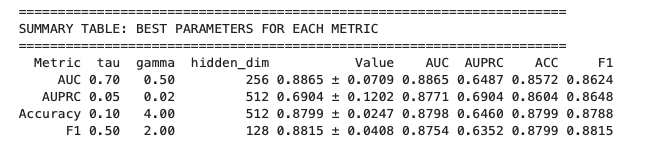

In [28]:
epochs = 300
patience = 30

best_gamma = 0.5
best_tau = 0.7
best_hidden_dim = 256

save_dir = f'/scratch/gilbreth/wang3712/Metastasis_single_cell/scMeta_LOOCV_final_rerun_gamma{best_gamma}_tau{best_tau}_dim{best_hidden_dim}/'


all_results, results_df = run_loocv(
    data=data,
    save_dir=save_dir,
    epochs=epochs,
    patience=patience,
    gamma=best_gamma,  # Best from 5-fold CV
    tau=best_tau,    # Best from 5-fold CV
    hidden_dim=best_hidden_dim  # Best from 5-fold CV
)


Total projects for LOOCV: 24

PROJECT 1/24: 2096-Lungcancer
Training: 458206 cells
Validation: 3629 cells, 8 patients

PRIOR BASELINE (Majority Class, Patient-Level)

Class distribution in validation:
  Primary (0): 8 patients
  Local (1):   0 patients
  Majority class: Primary (0)

Majority class prediction on 8 patients:
  Accuracy: 1.0000
  F1 Score: 1.0000
  ROC-AUC:  0.5000
  AUPRC:    -0.0000


Project: 2096-Lungcancer:   0%|          | 1/300 [00:13<1:05:29, 13.14s/it]


Epoch   0 | Loss: 480.1119
  [Cell-level]    Acc=0.9700, F1=0.0000, AUC=N/A    , AUPRC=N/A    
  [Patient-level] Acc=1.0000, F1=1.0000, AUC=N/A    , AUPRC=-0.0000
  Cell-level improved! Acc: 0.9700
  🌟 Patient-level improved! Acc: 1.0000
  Patience reset (both improved)


Project: 2096-Lungcancer:   3%|▎         | 10/300 [02:12<1:04:02, 13.25s/it]

  Cell-level improved! Acc: 0.9832
  Patience reset (cell-level improved, patient-level stable)


...


Epoch  50 | Loss: 422.2345
  [Cell-level]    Acc=0.7722, F1=0.4970, AUC=0.7804, AUPRC=0.5903
  [Patient-level] Acc=0.6667, F1=0.5333, AUC=0.8750, AUPRC=0.8333


Project: Zilionis_Klein_2019:  20%|██        | 61/300 [10:56<42:07, 10.58s/it]


Epoch  60 | Loss: 422.1564
  [Cell-level]    Acc=0.7716, F1=0.4418, AUC=0.7911, AUPRC=0.6160
  [Patient-level] Acc=0.6667, F1=0.5333, AUC=1.0000, AUPRC=1.0000


Project: Zilionis_Klein_2019:  22%|██▏       | 65/300 [11:50<42:47, 10.93s/it]


Early stopping at epoch 66
   No improvement in 30 epochs for either cell or patient metrics

✓ Saved best model: /scratch/gilbreth/wang3712/Metastasis_single_cell/scMeta_LOOCV_final_rerun_gamma0.5_tau0.7_dim256/Zilionis_Klein_2019/best_model.pt
✓ Saved results: /scratch/gilbreth/wang3712/Metastasis_single_cell/scMeta_LOOCV_final_rerun_gamma0.5_tau0.7_dim256/Zilionis_Klein_2019/results.pkl

SUMMARY FOR PROJECT Zilionis_Klein_2019
Best patient-level metrics (epoch 32):
  Acc:   0.8333
  F1:    0.8148
  AUC:   0.7500
  AUPRC: 0.7500
Best cell-level metrics (epoch 35):
  Acc:   0.7776
  AUC:   0.8094

LOOCV SUMMARY - ALL PROJECTS

✓ Saved: loocv_all_projects.csv
✓ Saved: loocv_summary.csv

Patient-level metrics (mean ± std across 24 projects):
  Acc:   0.8108 ± 0.2920
  AUC:   0.6375 ± 0.2887
  AUPRC:   0.3912 ± 0.4259
  f1:   0.7993 ± 0.3041

Cell-level metrics (mean ± std across 24 projects):
  Acc:   0.7546 ± 0.2510
  AUC:   0.6723 ± 0.1793


# LOOCV (Per-cancer)

## Data preperation

In [20]:
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data
import scanpy as sc

# ============================================================
# STEP 1: PREPARE CANCER-SPECIFIC DATA (NumPy/sklearn format)
# ============================================================

def prepare_cancer_specific_loocv_data(ad, cancer_type, cancer_mapping=None):
    """Prepare data for cancer-type-specific LOOCV."""
    
    print(f"\n{'='*70}")
    print(f"PREPARING DATA FOR {cancer_type}-SPECIFIC LOOCV")
    print(f"{'='*70}")
    
    # Auto-generate mapping if not provided
    if cancer_mapping is None:
        cancer_mapping = ad.obs.groupby('Final_cancer_type')['Project_ID'].apply(
            lambda x: sorted(list(x.unique()))
        ).to_dict()
    
    # Get projects for this cancer
    target_projects = cancer_mapping.get(cancer_type, [])
    
    if len(target_projects) == 0:
        print(f"ERROR: No projects found for {cancer_type}")
        return None
    
    print(f"Target projects for {cancer_type}: {target_projects}")
    
    # Filter data to specific cancer type
    cancer_mask = ad.obs['Project_ID'].isin(target_projects)
    ad_cancer = ad[cancer_mask].copy()
    
    print(f"\nFiltered data:")
    print(f"  Original: {ad.n_obs} cells")
    print(f"  {cancer_type}: {ad_cancer.n_obs} cells")
    
    # Get feature matrix
    X = ad_cancer.X
    
    # Prepare labels
    primary_mask = (ad_cancer.obs["Primary_or_Metastatic"] == "Primary").values
    local_mask = (ad_cancer.obs["Primary_or_Metastatic"] == "Metastatic") & \
                 (ad_cancer.obs["source"] == "local").values
    distant_mask = (ad_cancer.obs["Primary_or_Metastatic"] == "Metastatic") & \
                   (ad_cancer.obs["source"] == "distant").values
    
    # 3-class labels
    y_3class = np.full(X.shape[0], -1, dtype=int)
    y_3class[primary_mask] = 0
    y_3class[local_mask] = 1
    y_3class[distant_mask] = 2
    
    # Binary labels
    y_binary = np.full(X.shape[0], -1, dtype=int)
    y_binary[primary_mask] = 0
    y_binary[local_mask | distant_mask] = 1
    
    print(f"\nLabel distribution:")
    print(f"  Primary: {np.sum(y_3class == 0)} cells")
    print(f"  Local:   {np.sum(y_3class == 1)} cells")
    print(f"  Distant: {np.sum(y_3class == 2)} cells")
    
    # Get IDs
    project_ids = ad_cancer.obs["Project_ID"].values
    patient_ids = ad_cancer.obs["Final_sample_id"].values
    
    unique_projects = np.unique(project_ids)
    print(f"\nUnique projects in {cancer_type}: {len(unique_projects)}")
    
    # Build LOOCV folds
    print(f"\n{'='*70}")
    print("BUILDING LOOCV FOLDS")
    print(f"{'='*70}")
    
    loocv_folds = []
    
    for proj in unique_projects:
        val_mask = (project_ids == proj) & ((y_3class == 0) | (y_3class == 1))
        train_mask = project_ids != proj
        
        val_idx = np.where(val_mask)[0]
        train_idx = np.where(train_mask)[0]
        
        if len(val_idx) == 0:
            print(f"Skipping project {proj}: no valid primary/local samples.")
            continue
        
        val_patients = np.unique(patient_ids[val_idx])
        val_y = y_3class[val_idx]
        
        print(f"Project {proj}:")
        print(f"  Train: {len(train_idx)} cells")
        print(f"  Val:   {len(val_idx)} cells ({len(val_patients)} patients)")
        print(f"         Primary={np.sum(val_y == 0)}, Local={np.sum(val_y == 1)}")
        
        loocv_folds.append({
            "project": proj,
            "train_idx": train_idx,
            "val_idx": val_idx
        })
    
    print(f"\nTotal LOOCV folds for {cancer_type}: {len(loocv_folds)}")
    
    return {
        'cancer_type': cancer_type,
        'ad_cancer': ad_cancer,
        'X': X,
        'y_3class': y_3class,
        'y_binary': y_binary,
        'project_ids': project_ids,
        'patient_ids': patient_ids,
        'loocv_folds': loocv_folds,
        'unique_projects': unique_projects,
        'target_projects': target_projects
    }


def prepare_all_cancers_loocv_data(ad):
    """Prepare LOOCV data for ALL cancer types."""
    
    # Auto-generate cancer mapping
    cancer_mapping = ad.obs.groupby('Final_cancer_type')['Project_ID'].apply(
        lambda x: sorted(list(x.unique()))
    ).to_dict()
    
    print("\nDetected cancer types:")
    for cancer, projects in cancer_mapping.items():
        print(f"  {cancer}: {len(projects)} projects")
    
    # Prepare data for each cancer
    all_cancer_data = {}
    
    for cancer_type in sorted(cancer_mapping.keys()):
        cancer_data = prepare_cancer_specific_loocv_data(
            ad=ad,
            cancer_type=cancer_type,
            cancer_mapping=cancer_mapping
        )
        
        if cancer_data is not None:
            all_cancer_data[cancer_type] = cancer_data
    
    return all_cancer_data


# ============================================================
# STEP 2: CONVERT TO PYTORCH GEOMETRIC FORMAT
# ============================================================

def prepare_cancer_specific_pyg_data(cancer_data, recompute_graph=True):
    """Convert cancer-specific data to PyTorch Geometric format."""
    
    cancer_type = cancer_data['cancer_type']
    ad_cancer = cancer_data['ad_cancer']
    
    print(f"\n{'='*70}")
    print(f"PREPARING PyTorch DATA FOR {cancer_type}")
    print(f"{'='*70}")
    
    # Features
    if not isinstance(ad_cancer.X, np.ndarray):
        X = torch.tensor(ad_cancer.X.toarray(), dtype=torch.float32)
    else:
        X = torch.tensor(ad_cancer.X, dtype=torch.float32)
    
    print(f"Features: {X.shape}")
    
    # Graph edges
    if recompute_graph:
        print("Recomputing graph connectivity for cancer-specific data...")
        
        if 'connectivities' not in ad_cancer.obsp:
            print("  Computing neighbors...")
            sc.pp.neighbors(ad_cancer, n_neighbors=15, use_rep='X_pca_harmony')
        
        adj = ad_cancer.obsp["connectivities"].tocoo()
        edge_index = torch.tensor(np.vstack((adj.row, adj.col)), dtype=torch.long)
        print(f"  Edges: {edge_index.shape[1]}")
    else:
        adj = ad_cancer.obsp["connectivities"].tocoo()
        edge_index = torch.tensor(np.vstack((adj.row, adj.col)), dtype=torch.long)
        print(f"Edges: {edge_index.shape[1]}")
    
    # Labels
    y_3class = cancer_data['y_3class']
    y_binary = cancer_data['y_binary']
    
    y_3class_tensor = torch.tensor(y_3class, dtype=torch.long)
    
    # IDs
    project_ids = cancer_data['project_ids']
    patient_ids = cancer_data['patient_ids']
    
    # Create PyG Data object
    data = Data(
        x=X,
        edge_index=edge_index,
        y=y_3class_tensor
    )
    
    # Store additional info
    data.y_binary = y_binary
    data.patient_ids = patient_ids
    data.project_ids = project_ids
    data.cancer_type = cancer_type
    
    # Print summary
    print(f"\nDATA SUMMARY - {cancer_type}")
    print(f"{'='*70}")
    print(f"Nodes: {data.num_nodes}")
    print(f"Features: {data.num_node_features}")
    print(f"Edges: {data.edge_index.shape[1]}")
    print(f"Projects: {len(np.unique(project_ids))}")
    print(f"Patients: {len(np.unique(patient_ids))}")
    
    return data


def prepare_all_cancers_pyg_data(all_cancer_data, recompute_graph=True):
    """Prepare PyG Data objects for all cancer types."""
    
    all_pyg_data = {}
    
    for cancer_type, cancer_data in all_cancer_data.items():
        pyg_data = prepare_cancer_specific_pyg_data(
            cancer_data=cancer_data,
            recompute_graph=recompute_graph
        )
        all_pyg_data[cancer_type] = pyg_data
    
    return all_pyg_data


# ============================================================
# COMPLETE WORKFLOW - START HERE WITH JUST 'ad'
# ============================================================

# Step 1: Prepare cancer-specific data (NumPy format)
print("STEP 1: Preparing cancer-specific data...")
all_cancer_data = prepare_all_cancers_loocv_data(ad)

# Step 2: Convert to PyTorch Geometric format
print("\nSTEP 2: Converting to PyTorch Geometric format...")
all_pyg_data = prepare_all_cancers_pyg_data(all_cancer_data, recompute_graph=True)

# Now you have both:
# - all_cancer_data: dict with NumPy arrays for sklearn models
# - all_pyg_data: dict with PyG Data objects for PyTorch models

print(f"\n{'='*70}")
print("PREPARATION COMPLETE")
print(f"{'='*70}")
print(f"\nCancer types prepared: {list(all_pyg_data.keys())}")

for cancer_type in all_pyg_data.keys():
    pyg_data = all_pyg_data[cancer_type]
    cancer_data = all_cancer_data[cancer_type]
    print(f"\n{cancer_type}:")
    print(f"  Nodes: {pyg_data.num_nodes}")
    print(f"  LOOCV folds: {len(cancer_data['loocv_folds'])}")

STEP 1: Preparing cancer-specific data...

Detected cancer types:
  Breast Cancer: 5 projects
  Colorectal Cancer: 4 projects
  Lung Cancer: 12 projects
  Ovarian Cancer: 3 projects

PREPARING DATA FOR Breast Cancer-SPECIFIC LOOCV
Target projects for Breast Cancer: ['2102-Breastcancer', 'GSE225600', 'Multi_modal_breast_cancer', 'Single_cell_map_anti-PD1', 'Wu_etal_2021_BRCA']

Filtered data:
  Original: 461835 cells
  Breast Cancer: 119978 cells

Label distribution:
  Primary: 52278 cells
  Local:   4104 cells
  Distant: 63596 cells

Unique projects in Breast Cancer: 5

BUILDING LOOCV FOLDS
Project 2102-Breastcancer:
  Train: 113612 cells
  Val:   6366 cells (9 patients)
         Primary=6366, Local=0
Project GSE225600:
  Train: 117558 cells
  Val:   2420 cells (2 patients)
         Primary=0, Local=2420
Project Multi_modal_breast_cancer:
  Train: 54698 cells
  Val:   1684 cells (2 patients)
         Primary=0, Local=1684
Project Single_cell_map_anti-PD1:
  Train: 93599 cells
  Val:   

## Training

In [23]:

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score


def evaluate(model, x_val, y_binary, device):
    """
    Evaluate model on PRIMARY (0) vs NON-PRIMARY/METS (1).
    All cells are included (Primary, Local, Distant).
    
    Parameters:
    -----------
    model : nn.Module
        Model to evaluate
    x_val : torch.Tensor
        Validation features
    y_binary : torch.Tensor
        Binary labels (0=Primary, 1=Mets including Local+Distant)
    device : torch.device
        Device
    
    Returns:
    --------
    acc, f1, auc, auprc : float
        Evaluation metrics
    y_true, y_pred : np.array
        True and predicted labels
    """
    model.eval()
    
    # Self-loop edges
    N = x_val.size(0)
    edge_index_val = torch.arange(N, device=device).unsqueeze(0).repeat(2, 1)
    
    with torch.no_grad():
        logits, _ = model(x_val, edge_index=edge_index_val, return_embedding=True)
    
    # Get probabilities and predictions
    y_prob = torch.softmax(logits, dim=1)
    y_pred = logits.argmax(dim=1)
    
    # Convert to numpy
    y_true = y_binary.cpu().numpy()
    y_pred = y_pred.cpu().numpy()
    
    # This is better for Primary vs (Local+Distant)
    y_prob_mets_combined = (y_prob[:, 1] + y_prob[:, 2]).cpu().numpy()
    
    # For binary evaluation, map predictions: 0→0, {1,2}→1
    y_pred_binary = (y_pred >= 1).astype(int)
    
    # Compute metrics
    acc = accuracy_score(y_true, y_pred_binary)
    f1 = f1_score(y_true, y_pred_binary, zero_division=0)
    
    # Check if we have both classes
    if len(np.unique(y_true)) < 2:
        auc = np.nan
        auprc = np.nan
    else:
        try:
            # Use combined probability (Local + Distant)
            auc = roc_auc_score(y_true, y_prob_mets_combined)
        except Exception as e:
            print(f"[ERROR] AUC: {e}")
            auc = np.nan
        
        try:
            auprc = average_precision_score(y_true, y_prob_mets_combined)
        except Exception as e:
            print(f"[ERROR] AUPRC: {e}")
            auprc = np.nan
    
    return acc, f1, auc, auprc, y_true, y_pred_binary


def get_patient_level_statistics(data, fold, patient_ids):
    """
    Get patient-level statistics for a fold.
    
    Parameters:
    -----------
    data : Data
        Full PyG Data object
    fold : dict
        Fold definition with train_idx, val_idx, train_patients, val_patients
    patient_ids : np.array
        Patient IDs for all cells
    
    Returns:
    --------
    stats : dict
        Patient-level statistics
    """
    train_idx = fold['train_idx']
    val_idx = fold['val_idx']
    
    # Get patient IDs for train and val
    train_patients = patient_ids[train_idx]
    val_patients = patient_ids[val_idx]
    
    # Get labels
    y_train = data.y[train_idx].numpy()
    y_val = data.y[val_idx].numpy()
    
    # Count patients by type in training set
    train_patient_counts = {}
    for label, label_name in [(0, 'Primary'), (1, 'Local'), (2, 'Distant')]:
        label_mask = y_train == label
        patients_with_label = np.unique(train_patients[label_mask])
        cells_with_label = np.sum(label_mask)
        train_patient_counts[label_name] = {
            'n_patients': len(patients_with_label),
            'n_cells': cells_with_label
        }
    
    # Count patients by type in validation set
    val_patient_counts = {}
    for label, label_name in [(0, 'Primary'), (1, 'Local'), (2, 'Distant')]:
        label_mask = y_val == label
        patients_with_label = np.unique(val_patients[label_mask])
        cells_with_label = np.sum(label_mask)
        val_patient_counts[label_name] = {
            'n_patients': len(patients_with_label),
            'n_cells': cells_with_label
        }
    
    return {
        'train': train_patient_counts,
        'val': val_patient_counts,
        'train_patients': train_patients,
        'val_patients': val_patients
    }

def calculate_patient_level_metrics(model, x_val, y_binary, patient_ids_val, device):
    """
    Calculate patient-level metrics using majority vote.
    
    IMPORTANT: 
    - Validation patients have homogeneous labels (all Primary OR all Local)
    - TRUE labels are binary (0=Primary, 1=Local/Mets)
    - PREDICTED labels can be 0, 1, or 2 (model outputs 3 classes)
    - Score = pct_local + pct_distant (combined Mets probability)
    
    Parameters:
    -----------
    model : nn.Module
        Model to evaluate
    x_val : torch.Tensor
        Validation features
    y_binary : torch.Tensor
        Binary labels (0=Primary, 1=Mets) - CHANGED from y_val!
    patient_ids_val : np.array
        Patient IDs for validation cells
    device : torch.device
        Device
    
    Returns:
    --------
    metrics : dict
        Patient-level metrics
    """
    model.eval()
    N = x_val.size(0)
    edge_index_val = torch.arange(N, device=device).unsqueeze(0).repeat(2, 1)
    
    with torch.no_grad():
        logits, _ = model(x_val, edge_index=edge_index_val, return_embedding=True)
    
    # Cell-level predictions (can be 0, 1, or 2)
    y_pred_cells = logits.argmax(dim=1).cpu().numpy()
    y_true_cells = y_binary.cpu().numpy()  # ✅ Binary labels (0 or 1)
    
    # Aggregate to patient level
    unique_patients = np.unique(patient_ids_val)
    
    patient_results = []
    
    for patient_id in unique_patients:
        patient_mask = patient_ids_val == patient_id
        
        # Get true label for patient (should be consistent for all cells)
        patient_true = y_true_cells[patient_mask][0]  # Binary: 0 or 1
        
        # Verify homogeneity (all cells should have same true label)
        assert np.all(y_true_cells[patient_mask] == patient_true), \
            f"Patient {patient_id} has heterogeneous labels! This should not happen."
        
        # Count predictions per class (predictions can be 0, 1, or 2)
        patient_preds = y_pred_cells[patient_mask]
        n_cells = len(patient_preds)
        
        # Calculate percentages for each predicted class
        pred_counts = np.bincount(patient_preds, minlength=3)
        pct_primary = (pred_counts[0] / n_cells) * 100
        pct_local = (pred_counts[1] / n_cells) * 100
        pct_distant = (pred_counts[2] / n_cells) * 100
        
        # Patient-level prediction: Primary (0) vs Mets (1)
        # If majority of cells predicted as Primary → 0, otherwise → 1
        patient_pred = 0 if (pct_primary > (pct_local+pct_distant)) else 1
        
        patient_results.append({
            'patient_id': patient_id,
            'true_label': patient_true,  # Binary: 0 or 1
            'pred_label': patient_pred,   # Binary: 0 or 1
            'pct_primary': pct_primary,
            'pct_local': pct_local,
            'pct_distant': pct_distant,
            'n_cells': n_cells
        })
    
    # Convert to DataFrame
    df = pd.DataFrame(patient_results)
    
    # All patients should already be Primary (0) or Local (1)
    # No filtering needed!
    if len(df) == 0:
        return {
            'acc': np.nan,
            'f1': np.nan,
            'auc': np.nan,
            'auprc': np.nan,
            'n_patients': 0
        }
    
    # Binary metrics
    y_true_bin = df['true_label'].values  # Already binary: 0 or 1
    y_pred_bin = df['pred_label'].values  # Already binary: 0 or 1
    
    # Combined Mets probability (Local + Distant)
    y_scores = (df['pct_local'] + df['pct_distant']).values
    
    # Verify all labels are binary
    assert np.all(np.isin(y_true_bin, [0, 1])), "True labels should only be 0 or 1!"
    
    # Calculate metrics
    try:
        auc = roc_auc_score(y_true_bin, y_scores)
    except:
        auc = np.nan
    
    try:
        auprc = average_precision_score(y_true_bin, y_scores)
    except:
        auprc = np.nan
    
    acc = accuracy_score(y_true_bin, y_pred_bin)
    f1 = f1_score(y_true_bin, y_pred_bin, average='weighted', zero_division=0)
    
    return {
        'acc': acc,
        'f1': f1,
        'auc': auc,
        'auprc': auprc,
        'n_patients': len(df),
        'patient_results': df
    }


def calculate_majority_class_prior(y_val, patient_ids_val):
    """
    Calculate prior metrics using majority class prediction.
    
    FIXED: Correct F1 calculation and AUC/AUPRC for majority baseline.
    """
    
    if isinstance(y_val, torch.Tensor):
        y_val = y_val.cpu().numpy()
    
    # Determine majority class at PATIENT level
    unique_patients = np.unique(patient_ids_val)
    patient_true_labels = []
    
    for patient_id in unique_patients:
        patient_mask = patient_ids_val == patient_id
        patient_true = y_val[patient_mask][0]
        patient_true_labels.append(patient_true)
    
    patient_true_labels = np.array(patient_true_labels)
    
    # Find majority class
    class_counts = np.bincount(patient_true_labels)
    majority_class = np.argmax(class_counts)
    
    print(f"\nClass distribution in validation:")
    print(f"  Primary (0): {np.sum(patient_true_labels == 0)} patients")
    print(f"  Local (1):   {np.sum(patient_true_labels == 1)} patients")
    print(f"  Majority class: {'Primary' if majority_class == 0 else 'Local'} ({majority_class})")
    
    # Predict everything as majority class
    y_pred_majority = np.full(len(patient_true_labels), majority_class)
    
    # For AUC/AUPRC, we need scores for the POSITIVE class (Local = 1)
    if majority_class == 0:
        # Predicting Primary (0), so score for Local (1) = 0%
        y_scores = np.full(len(patient_true_labels), 0.0)  # 0% Local
    else:
        # Predicting Local (1), so score for Local (1) = 100%
        y_scores = np.full(len(patient_true_labels), 100.0)  # 100% Local
    
    # Calculate metrics
    y_true = patient_true_labels
    y_pred = y_pred_majority
    
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # AUC/AUPRC for constant predictions
    try:
        auc = roc_auc_score(y_true, y_scores)
    except:
        auc = 0.5  # Random guess baseline
    
    try:
        auprc = average_precision_score(y_true, y_scores)
    except:
        # AUPRC baseline = proportion of positive class
        auprc = np.mean(y_true == 1)
    
    return {
        'acc': acc,
        'f1': f1,
        'auc': auc,
        'auprc': auprc,
        'n_patients': len(patient_true_labels),
        'majority_class': majority_class,
        'baseline_type': 'majority_class'
    }

# Helper function for formatting (add at top of function)
def format_metric(value):
    """Format metric value, handling NaN."""
    if np.isnan(value):
        return "N/A"
    else:
        return f"{value:.4f}"

In [24]:
# Contrastive loss
def NT_Xent(embeddings, tau=0.5):
    device = embeddings.device
    z_i = F.normalize(embeddings, dim=1)
    z_j = F.normalize(embeddings[torch.randperm(z_i.size(0))], dim=1)
    logits = torch.mm(z_i, z_j.t()) / tau
    labels = torch.arange(z_i.size(0), device=device)
    loss = F.cross_entropy(logits, labels)
    return loss


In [25]:
def run_loocv(
    data, 
    save_dir, 
    epochs=100, 
    patience=10, 
    gamma=0.1, 
    tau=0.5, 
    hidden_dim=128
):
    """
    Run LOOCV for scMeta model.
    Saves best model based on patient-level accuracy.
    Resets patience if either cell-level OR patient-level metrics improve.
    """
    
    # Suppress sklearn warnings
    import warnings
    from sklearn.exceptions import UndefinedMetricWarning
    warnings.filterwarnings('ignore', category=UndefinedMetricWarning)
    warnings.filterwarnings('ignore', message='No positive class found in y_true')
    
    os.makedirs(save_dir, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Get data from prepared object
    project_ids = data.project_ids
    patient_ids = data.patient_ids
    y_binary = data.y_binary
    y_3class = data.y.numpy()
    
    # Get unique projects
    unique_projects = np.unique(project_ids)
    print(f"\nTotal projects for LOOCV: {len(unique_projects)}")
    
    all_results = []
    
    # ============================================================
    # LOOP OVER PROJECTS
    # ============================================================
    
    for proj_idx, project in enumerate(unique_projects):
        print(f"\n{'='*70}")
        print(f"PROJECT {proj_idx + 1}/{len(unique_projects)}: {project}")
        print(f"{'='*70}")
        
        project_save_dir = os.path.join(save_dir, str(project).replace("/", "_"))
        os.makedirs(project_save_dir, exist_ok=True)
        
        best_model_path = os.path.join(project_save_dir, f"best_model.pt")
        results_path = os.path.join(project_save_dir, f"results.pkl")
        
        # Check if already processed
        if os.path.exists(results_path):
            print(f"✓ Already processed, loading results...")
            import joblib
            result = joblib.load(results_path)
            all_results.append(result)
            continue
        
        # ============================================================
        # CREATE TRAIN/VAL SPLIT
        # ============================================================
        
        # Validation: Primary or Local cells from this project ONLY
        project_mask = (project_ids == project)
        val_mask = project_mask & ((y_3class == 0) | (y_3class == 1))
        
        # Training: All cells from other projects (including distant mets)
        train_mask_np = project_ids != project
        
        val_idx = np.where(val_mask)[0]
        train_idx = np.where(train_mask_np)[0]
        
        if len(val_idx) == 0:
            print(f"Skipping: no valid primary/local samples.")
            continue
        
        # Get validation data
        val_patients = np.unique(patient_ids[val_idx])
        
        print(f"Training: {len(train_idx)} cells")
        print(f"Validation: {len(val_idx)} cells, {len(val_patients)} patients")
        
        # ============================================================
        # PREPARE TRAINING DATA
        # ============================================================
        
        train_mask_torch = torch.zeros(data.num_nodes, dtype=torch.bool)
        train_mask_torch[train_idx] = True
        
        # Build train graph
        edge_index_train, _ = subgraph(train_mask_torch, data.edge_index, relabel_nodes=True)
        x_train = data.x[train_mask_torch]
        y_train = data.y[train_mask_torch]
        
        train_data = Data(
            x=x_train,
            edge_index=edge_index_train,
            y=y_train
        )
        
        # ============================================================
        # PREPARE VALIDATION DATA
        # ============================================================
        
        x_val = data.x[val_idx].to(device)
        y_val_3class = data.y[val_idx]  # 3-class (for predictions)
        y_val_binary = torch.tensor(y_binary[val_idx], dtype=torch.long).to(device)  # Binary (for eval)
        patient_ids_val = patient_ids[val_idx]
        
        # ============================================================
        # INITIALIZE MODEL
        # ============================================================
        
        model = scMeta(
            input_dim=data.num_node_features,
            hidden_dim=hidden_dim,
            num_classes=len(torch.unique(data.y))
        ).to(device)
        
        optimizer = optim.Adam(model.parameters(), lr=1e-4)
        
        # Initialize best metrics
        best_metrics_cell = {
            'acc': 0.0,
            'f1': 0.0,
            'auc': 0.0,
            'auprc': 0.0,
            'epoch': -1
        }
        
        best_metrics_patient = {
            'acc': 0.0,
            'f1': 0.0,
            'auc': 0.0,
            'auprc': 0.0,
            'epoch': -1
        }
        
        best_model_state = None
        patience_counter = 0
        
        # ============================================================
        # CALCULATE PRIOR (MAJORITY CLASS BASELINE)
        # ============================================================
        
        print(f"\n{'='*60}")
        print("PRIOR BASELINE (Majority Class, Patient-Level)")
        print(f"{'='*60}")
        
        prior_metrics = calculate_majority_class_prior(
            y_val_binary, patient_ids_val
        )
        
        print(f"\nMajority class prediction on {prior_metrics['n_patients']} patients:")
        print(f"  Accuracy: {prior_metrics['acc']:.4f}")
        print(f"  F1 Score: {prior_metrics['f1']:.4f}")
        if not np.isnan(prior_metrics['auc']):
            print(f"  ROC-AUC:  {prior_metrics['auc']:.4f}")
        else:
            print(f"  ROC-AUC:  N/A (constant prediction)")
        if not np.isnan(prior_metrics['auprc']):
            print(f"  AUPRC:    {prior_metrics['auprc']:.4f}")
        else:
            print(f"  AUPRC:    N/A (constant prediction)")
        
        # ============================================================
        # TRAINING LOOP
        # ============================================================
        
        for epoch in tqdm(range(epochs), desc=f"Project: {project}"):
            model.train()
            total_loss = 0
            
            loader = RandomNodeLoader(train_data, num_parts=100, shuffle=True)
            
            for batch in loader:
                batch = batch.to(device)
                logits, emb = model(batch.x, batch.edge_index, return_embedding=True)
                
                loss_ce = F.cross_entropy(logits, batch.y)
                loss_con = NT_Xent(emb, tau=tau)
                loss = loss_ce + gamma * loss_con
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                total_loss += loss.item()
            
            # ============================================================
            # EVALUATION (Every Epoch)
            # ============================================================
            
            # Cell-level metrics
            acc_cell, f1_cell, auc_cell, auprc_cell, _, _ = evaluate(
                model, x_val, y_val_binary, device
            )
            
            # Patient-level metrics
            patient_metrics = calculate_patient_level_metrics(
                model, x_val, y_val_binary, patient_ids_val, device
            )
            
            # ============================================================
            # PRINT PROGRESS (Every 10 Epochs)
            # ============================================================
            
            if epoch % 10 == 0 or epoch == 0:
                def format_metric(value):
                    """Format metric value, handling NaN."""
                    if np.isnan(value):
                        return "N/A    "
                    else:
                        return f"{value:.4f}"
                
                print(f"\nEpoch {epoch:3d} | Loss: {total_loss:.4f}")
                print(f"  [Cell-level]    Acc={format_metric(acc_cell)}, F1={format_metric(f1_cell)}, "
                      f"AUC={format_metric(auc_cell)}, AUPRC={format_metric(auprc_cell)}")
                print(f"  [Patient-level] Acc={format_metric(patient_metrics['acc'])}, F1={format_metric(patient_metrics['f1'])}, "
                      f"AUC={format_metric(patient_metrics['auc'])}, AUPRC={format_metric(patient_metrics['auprc'])}")
            
            # ============================================================
            # TRACK BEST MODEL WITH DUAL PATIENCE
            # ============================================================
            
            improved_cell = False
            improved_patient = False
            
            # Track best cell-level (using accuracy for consistency)
            if acc_cell > best_metrics_cell['acc']:
                best_metrics_cell = {
                    'acc': acc_cell,
                    'f1': f1_cell,
                    'auc': auc_cell,
                    'auprc': auprc_cell,
                    'epoch': epoch
                }
                improved_cell = True
                print(f"  Cell-level improved! Acc: {acc_cell:.4f}")
            
            # Track best patient-level (primary metric for model saving)
            if patient_metrics['acc'] > best_metrics_patient['acc']:
                best_metrics_patient = {
                    'acc': patient_metrics['acc'],
                    'f1': patient_metrics['f1'],
                    'auc': patient_metrics['auc'],
                    'auprc': patient_metrics['auprc'],
                    'epoch': epoch
                }
                improved_patient = True
                print(f"  🌟 Patient-level improved! Acc: {patient_metrics['acc']:.4f}")
                
                # Save model when patient-level improves
                best_model_state = model.state_dict().copy()
            
            # DUAL PATIENCE: Reset if EITHER cell or patient improved
            if improved_cell or improved_patient:
                patience_counter = 0
                if improved_cell and not improved_patient:
                    print(f"  Patience reset (cell-level improved, patient-level stable)")
                elif improved_patient and not improved_cell:
                    print(f"  Patience reset (patient-level improved)")
                else:
                    print(f"  Patience reset (both improved)")
            else:
                patience_counter += 1
                # print(f"  Patience: {patience_counter}/{patience}")
                
                if patience_counter >= patience:
                    print(f"\nEarly stopping at epoch {epoch + 1}")
                    print(f"   No improvement in {patience} epochs for either cell or patient metrics")
                    break
        
        # ============================================================
        # SAVE BEST MODEL AND RESULTS
        # ============================================================
        
        if best_model_state is not None:
            torch.save(best_model_state, best_model_path)
            print(f"\n✓ Saved best model: {best_model_path}")
        else:
            print(f"\nNo improvement found, saving final model state")
            torch.save(model.state_dict(), best_model_path)
            # Use final epoch metrics
            best_metrics_patient = {
                'acc': patient_metrics['acc'],
                'f1': patient_metrics['f1'],
                'auc': patient_metrics['auc'],
                'auprc': patient_metrics['auprc'],
                'epoch': epoch
            }
        
        # Save results
        result = {
            'project': project,
            'n_cells': len(val_idx),
            'n_patients': len(val_patients),
            # Cell-level metrics (best)
            'cell_acc': best_metrics_cell['acc'],
            'cell_f1': best_metrics_cell['f1'],
            'cell_auc': best_metrics_cell['auc'],
            'cell_auprc': best_metrics_cell['auprc'],
            'cell_best_epoch': best_metrics_cell['epoch'],
            # Patient-level metrics (best - used for model selection)
            'patient_acc': best_metrics_patient['acc'],
            'patient_f1': best_metrics_patient['f1'],
            'patient_auc': best_metrics_patient['auc'],
            'patient_auprc': best_metrics_patient['auprc'],
            'patient_best_epoch': best_metrics_patient['epoch'],
            # Prior baseline
            'prior_acc': prior_metrics['acc'],
            'prior_f1': prior_metrics['f1'],
            'prior_auc': prior_metrics['auc'],
            'prior_auprc': prior_metrics['auprc']
        }
        
        import joblib
        joblib.dump(result, results_path)
        print(f"✓ Saved results: {results_path}")
        
        all_results.append(result)
        
        # Print summary
        print(f"\n{'='*60}")
        print(f"SUMMARY FOR PROJECT {project}")
        print(f"{'='*60}")
        print(f"Best patient-level metrics (epoch {best_metrics_patient['epoch']}):")
        print(f"  Acc:   {best_metrics_patient['acc']:.4f}")
        print(f"  F1:    {best_metrics_patient['f1']:.4f}")
        print(f"  AUC:   {format_metric(best_metrics_patient['auc'])}")  
        print(f"  AUPRC: {format_metric(best_metrics_patient['auprc'])}")  
        print(f"Best cell-level metrics (epoch {best_metrics_cell['epoch']}):")
        print(f"  Acc:   {format_metric(best_metrics_cell['acc'])}")
        print(f"  AUC:   {format_metric(best_metrics_cell['auc'])}")  

    
    # ============================================================
    # AGGREGATE RESULTS ACROSS ALL PROJECTS
    # ============================================================
    
    print(f"\n{'='*70}")
    print("LOOCV SUMMARY - ALL PROJECTS")
    print(f"{'='*70}")
    
    results_df = pd.DataFrame(all_results)
    
    # Save detailed results
    results_df.to_csv(os.path.join(save_dir, 'loocv_all_projects.csv'), index=False)
    print(f"\n✓ Saved: loocv_all_projects.csv")
    
    # Calculate summary
    summary = {
        'n_projects': len(all_results),
        # Cell-level
        'mean_cell_acc': results_df['cell_acc'].mean(),
        'std_cell_acc': results_df['cell_acc'].std(),
        'mean_cell_auc': results_df['cell_auc'].mean(),
        'std_cell_auc': results_df['cell_auc'].std(),
        # Patient-level
        'mean_patient_acc': results_df['patient_acc'].mean(),
        'mean_patient_auprc': results_df['patient_auprc'].mean(),
        'mean_patient_auc': results_df['patient_auc'].mean(),
        'mean_patient_f1': results_df['patient_f1'].mean(),
        'std_patient_acc': results_df['patient_acc'].std(),
        'std_patient_auprc': results_df['patient_auprc'].std(),
        'std_patient_auc': results_df['patient_auc'].std(),
        'std_patient_f1': results_df['patient_f1'].std(),
    }
    
    summary_df = pd.DataFrame([summary])
    summary_df.to_csv(os.path.join(save_dir, 'loocv_summary.csv'), index=False)
    print(f"✓ Saved: loocv_summary.csv")
    
    print(f"\nPatient-level metrics (mean ± std across {len(all_results)} projects):")
    print(f"  Acc:   {summary['mean_patient_acc']:.4f} ± {summary['std_patient_acc']:.4f}")
    print(f"  AUC:   {summary['mean_patient_auc']:.4f} ± {summary['std_patient_auc']:.4f}")
    print(f"  AUPRC:   {summary['mean_patient_auprc']:.4f} ± {summary['std_patient_auprc']:.4f}")
    print(f"  f1:   {summary['mean_patient_f1']:.4f} ± {summary['std_patient_f1']:.4f}")
    
    print(f"\nCell-level metrics (mean ± std across {len(all_results)} projects):")
    print(f"  Acc:   {summary['mean_cell_acc']:.4f} ± {summary['std_cell_acc']:.4f}")
    print(f"  AUC:   {summary['mean_cell_auc']:.4f} ± {summary['std_cell_auc']:.4f}")
    
    return all_results, results_df

In [26]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning

# Suppress sklearn warnings about single-class AUPRC
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)
warnings.filterwarnings('ignore', message='No positive class found in y_true')

In [29]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# RUN CANCER-SPECIFIC LOOCV FOR ALL CANCERS
# ============================================================

def run_cancer_specific_loocv_pytorch(
    all_pyg_data,
    base_save_dir="/scratch/negishi/wang3712/Metastasis_single_cell/PyTorch_Cancer_Specific_LOOCV/",
    epochs=100,
    patience=10,
    gamma=0.1,
    tau=0.5,
    hidden_dim=128
):
    """
    Run PyTorch LOOCV for each cancer type separately.
    
    Parameters:
    -----------
    all_pyg_data : dict
        Dict of cancer_type -> PyG Data object
        (Output from prepare_all_cancers_pyg_data)
    base_save_dir : str
        Base directory for saving results
    epochs, patience, gamma, tau, hidden_dim : 
        Model hyperparameters
    
    Returns:
    --------
    all_cancer_results : dict
        Results for each cancer type
    """
    
    print(f"\n{'#'*70}")
    print("CANCER-SPECIFIC PYTORCH LOOCV FOR ALL CANCER TYPES")
    print(f"{'#'*70}")
    
    base_save_dir = Path(base_save_dir)
    base_save_dir.mkdir(parents=True, exist_ok=True)
    
    all_cancer_results = {}
    all_summaries = []
    
    # ============================================================
    # PROCESS EACH CANCER TYPE
    # ============================================================
    
    for cancer_idx, (cancer_type, pyg_data) in enumerate(all_pyg_data.items()):
        
        print(f"\n{'='*70}")
        print(f"CANCER {cancer_idx + 1}/{len(all_pyg_data)}: {cancer_type}")
        print(f"{'='*70}")
        
        # Get unique projects for this cancer
        unique_projects = np.unique(pyg_data.project_ids)
        
        print(f"Data summary:")
        print(f"  Nodes: {pyg_data.num_nodes}")
        print(f"  Features: {pyg_data.num_node_features}")
        print(f"  Edges: {pyg_data.edge_index.shape[1]}")
        print(f"  Projects: {len(unique_projects)}")
        print(f"  Project list: {list(unique_projects)}")
        
        # Check if enough projects for LOOCV
        if len(unique_projects) < 2:
            print(f"WARNING: Only {len(unique_projects)} project(s) for {cancer_type}. Skipping LOOCV.")
            continue
        
        # Create save directory for this cancer
        cancer_save_dir = base_save_dir / cancer_type
        cancer_save_dir.mkdir(parents=True, exist_ok=True)
        
        # ============================================================
        # RUN LOOCV (using your existing function!)
        # ============================================================
        
        print(f"\nRunning LOOCV for {cancer_type}...")
        print(f"Save directory: {cancer_save_dir}")
        
        try:
            from datetime import datetime
            start_time = datetime.now()
            
            # YOUR EXISTING FUNCTION - works as-is!
            all_results, results_df = run_loocv(
                data=pyg_data,  # Cancer-specific PyG Data object
                save_dir=str(cancer_save_dir),
                epochs=epochs,
                patience=patience,
                gamma=gamma,
                tau=tau,
                hidden_dim=hidden_dim
            )
            
            end_time = datetime.now()
            total_time = end_time - start_time
            
            # Store results
            all_cancer_results[cancer_type] = {
                'all_results': all_results,
                'results_df': results_df,
                'n_projects': len(all_results),
                'total_time': str(total_time)
            }
            
            # Add to summary
            all_summaries.append({
                'cancer_type': cancer_type,
                'n_projects': len(all_results),
                'mean_patient_acc': results_df['patient_acc'].mean(),
                'std_patient_acc': results_df['patient_acc'].std(),
                'mean_patient_auc': results_df['patient_auc'].mean(),
                'std_patient_auc': results_df['patient_auc'].std(),
                'mean_patient_f1': results_df['patient_f1'].mean(),
                'std_patient_f1': results_df['patient_f1'].std(),
                'mean_patient_auprc': results_df['patient_auprc'].mean(),
                'std_patient_auprc': results_df['patient_auprc'].std(),
                'total_time': str(total_time)
            })
            
            print(f"\n{'='*70}")
            print(f"COMPLETED {cancer_type} in {total_time}")
            print(f"{'='*70}")
            
        except Exception as e:
            print(f"\nERROR with {cancer_type}: {str(e)}")
            import traceback
            traceback.print_exc()
            continue
    
    # ============================================================
    # COMPARE ACROSS CANCER TYPES
    # ============================================================
    
    if len(all_summaries) > 0:
        print(f"\n{'='*70}")
        print("COMPARISON ACROSS CANCER TYPES")
        print(f"{'='*70}")
        
        comparison_df = pd.DataFrame(all_summaries)
        comparison_df = comparison_df.sort_values('mean_patient_auc', ascending=False)
        
        print("\nResults by cancer type (sorted by Patient AUC):")
        print(comparison_df[['cancer_type', 'n_projects', 'mean_patient_acc', 'mean_patient_auc', 'mean_patient_f1']].to_string(index=False))
        
        # Save comparison
        comparison_file = base_save_dir / "all_cancers_comparison.csv"
        comparison_df.to_csv(comparison_file, index=False)
        print(f"\nSaved: {comparison_file}")
        
        # Print detailed summary
        print(f"\n{'='*70}")
        print("DETAILED SUMMARY BY CANCER TYPE")
        print(f"{'='*70}")
        
        for _, row in comparison_df.iterrows():
            print(f"\n{row['cancer_type']}:")
            print(f"  Projects evaluated: {row['n_projects']}")
            print(f"  Patient Acc: {row['mean_patient_acc']:.4f} ± {row['std_patient_acc']:.4f}")
            print(f"  Patient AUC: {row['mean_patient_auc']:.4f} ± {row['std_patient_auc']:.4f}")
            print(f"  Patient F1:  {row['mean_patient_f1']:.4f} ± {row['std_patient_f1']:.4f}")
            print(f"  Patient AUPRC: {row['mean_patient_auprc']:.4f} ± {row['std_patient_auprc']:.4f}")
            print(f"  Time: {row['total_time']}")
    
    return all_cancer_results, comparison_df

In [ ]:
epochs = 300
patience = 30

best_gamma = 0.5
best_tau = 0.7
best_hidden_dim = 256

save_dir = f'/scratch/gilbreth/wang3712/Metastasis_single_cell/scMeta_LOOCV_per_cancer_final_rerun_gamma{best_gamma}_tau{best_tau}_dim{best_hidden_dim}/'

all_cancer_results, comparison_df = run_cancer_specific_loocv_pytorch(
    all_pyg_data=all_pyg_data,
    base_save_dir=save_dir,
    epochs=epochs,
    patience=patience,
    gamma=best_gamma,
    tau=best_tau,
    hidden_dim=best_hidden_dim
)
